In [42]:
# Architect we're building
# Input (64 pixels) → Hidden Layer (64 neurons) → Output (10 digits)

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [44]:
# Load MNIST
digits = load_digits()
X, y = digits.data, digits.target

In [45]:
# Normalization makes training faster, stable, and prevents any one feature from dominating just because its number is bigger.

In [46]:
# Normalize
X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [47]:
print(f"Training samples: {X_train.shape}")
print(f"Test samples: {X_test.shape}")
print(f"Total samples: {X.shape}")
print(f"Features per sample: {X.shape[1]}")
print(f"Classes: {np.unique(y)}")

Training samples: (1437, 64)
Test samples: (360, 64)
Total samples: (1797, 64)
Features per sample: 64
Classes: [0 1 2 3 4 5 6 7 8 9]


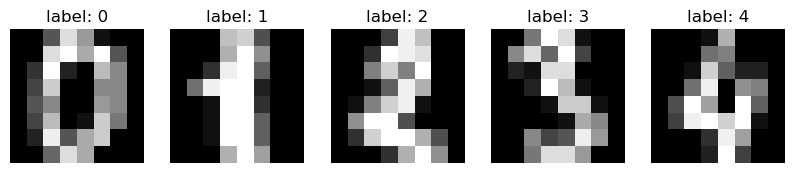

In [48]:
# Visualzie first 5 digits
fig, axes = plt.subplots(1, 5, figsize=(10,3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'label: {y[i]}')
    ax.axis('off')
plt.show()

In [49]:
# initializing the weights and biases
# w1 (64, 64) → connects 64 pixels to 64 hidden neurons
# w2 (64, 10) → connects 64 hidden neurons to 10 output digits

np.random.seed(23)

input_size = 64  # 64 pixels per image
hidden_size = 64 # 64 neurons in hidden layer
output_size = 10 # 10 digits (0-9)

# weights
w1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

w2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

print(f"W1 shape: {w1.shape}")
print(f"W2 shape: {w2.shape}")
print("Network initialized!")

W1 shape: (64, 64)
W2 shape: (64, 10)
Network initialized!


In [50]:
# Activation functions
def relu(z): # Hidden layer
    return np.maximum(0, z)
    # z → the input (could be any number, negative or positive)
    # np.maximum(0, z) → compares 0 and z, returns whichever is bigger
    # So negative values become 0, positive values stay as is

def relu_derivative(z): # For Backpropagation
    return (z > 0).astype(float)
    # (z > 0) → returns True/False for each value, .astype(float) → converts True→1.0, False→0.0
    # Used during backprop to tell the network — “this neuron was active, update it. This one was dead, skip it.”

def softmax(z): # Output Layer
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    # Softmax = make all scores positive → divide by total → get probabilities

print("Activation functions ready!")

Activation functions ready!


In [51]:
# Forward Propagation
# Input → W1,b1 → ReLU → W2,b2 → Softmax → Prediction
def forward_pass(X, w1, b1, w2, b2):
    # Layer 1
    Z1 = np.dot(X, w1) + b1 # linear step
    A1 = relu(Z1) # Activation

    # Layer 2
    Z2 = np.dot(A1, w2) + b2 # linear step
    A2= softmax(Z2) # probabilities

    return Z1, A1, Z2, A2

In [52]:
# Testing on one image
Z1, A1, Z2, A2 = forward_pass(X_train, w1, b1, w2, b2)

print(f"Z1 shape: {Z1.shape}")
print(f"A1 shape: {A1.shape}")
print(f"Z2 shape: {Z2.shape}")
print(f"A2 shape: {A2.shape}")
print(f"\nFirst prediction probabilities:\n{A2[0]}")
print(f"Predicted digit: {np.argmax(A2[0])}")
print(f"Actual digit: {y_train[0]}")

Z1 shape: (1437, 64)
A1 shape: (1437, 64)
Z2 shape: (1437, 10)
A2 shape: (1437, 10)

First prediction probabilities:
[0.1004211  0.10027403 0.09975972 0.10025477 0.1000016  0.09983541
 0.09991266 0.09978643 0.0998818  0.09987247]
Predicted digit: 0
Actual digit: 9


In [53]:
# Weights are still random, network is just guessing.
# All 10 probabilities are ~0.10 each — literally equal guessing, like flipping a 10-sided coin.
# This is exactly WHY we need training — to fix those random weights.

In [54]:
# Loss + Backprop + Training
def comput_loss(A2, y):
    m = y.shape[0]
    log_probs = -np.log(A2[range(m), y] + 1e-8)  # Loss = -(1/m) * sum( log(A2[i, y_i] + 1e-8)
    return np.mean(log_probs)

def backward_pass(X, y, Z1, A1, Z2, A2, w2):
    m = y.shape[0]

    dZ2 = A2.copy()
    dZ2[range(m), y] -= 1
    dZ2 /= m  # dZ2 = (A2 - Y_onehot) / m

    dw2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis = 0, keepdims=True)
    # dw2 = (1/m) * A1.T · dZ2
    # db2 = (1/m) * sum(dZ2)

    dA1 = np.dot(dZ2, w2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    # dA1 = dZ2 · W2.T
    # dZ1 = dA1 * ReLU'(Z1)

    dw1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    # dW1 = (1/m) * X.T · dZ1
    # db1 = (1/m) * sum(dZ1)

    return dw1, db1, dw2, db2

In [55]:
# Training Loops
learning_rate = 0.1
epochs = 1000
losses = []

for epoch in range(epochs):
    Z1, A1, Z2, A2 = forward_pass(X_train, w1, b1, w2, b2)
    loss = comput_loss(A2, y_train)
    losses.append(loss)

    dw1, db1, dw2, db2 = backward_pass(X_train, y_train, Z1, A1, Z2, A2, w2)

    w1 -= learning_rate * dw1
    b1 -= learning_rate * db1
    w2 -= learning_rate * dw2
    b2 -= learning_rate * db2
    # w/b = w/b - lr * dw (/ -> either)
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch} | Loss: {loss:.4f}')

print("Training Completed!")

Epoch 0 | Loss: 2.3025
Epoch 100 | Loss: 2.2409
Epoch 200 | Loss: 1.3761
Epoch 300 | Loss: 0.6472
Epoch 400 | Loss: 0.4037
Epoch 500 | Loss: 0.2959
Epoch 600 | Loss: 0.2355
Epoch 700 | Loss: 0.1970
Epoch 800 | Loss: 0.1703
Epoch 900 | Loss: 0.1506
Training Completed!


✅ Test Accuracy: 95.56%


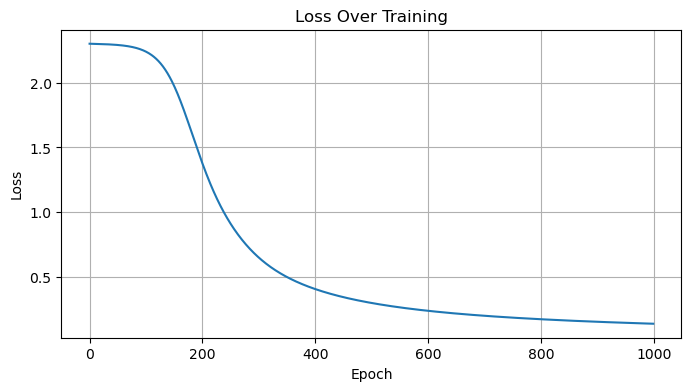

In [56]:
# Accuracy + Loss Curve
_, _, _, A2_test = forward_pass(X_test, w1, b1, w2, b2)
predictions = np.argmax(A2_test, axis=1)
accuracy = np.mean(predictions == y_test) * 100
print(f"✅ Test Accuracy: {accuracy:.2f}%")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Loss Over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

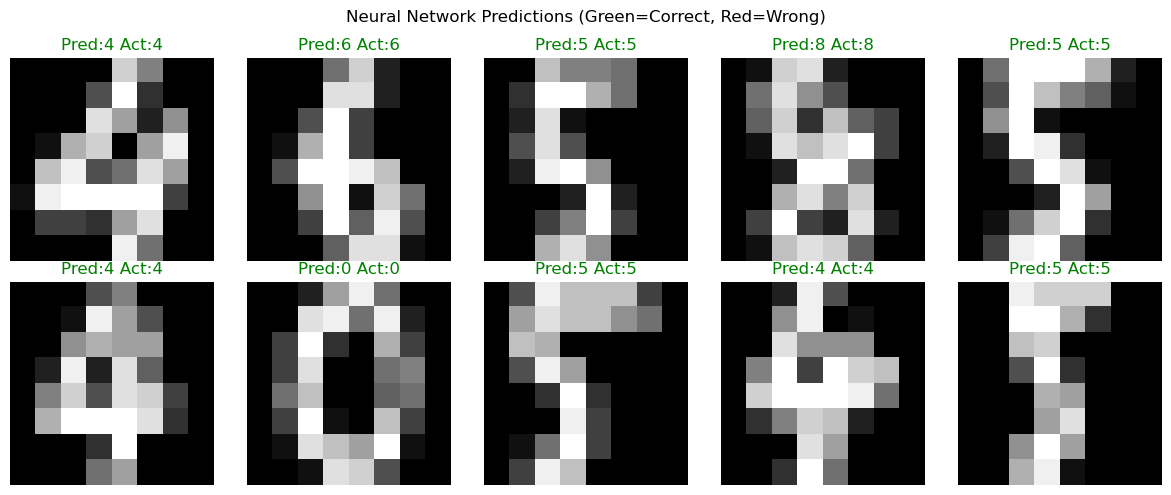

In [57]:
# Visualize Predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    pred = predictions[i]
    actual = y_test[i]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f"Pred:{pred} Act:{actual}", color=color)
    ax.axis('off')

plt.suptitle("Neural Network Predictions (Green=Correct, Red=Wrong)", 
             fontsize=12)
plt.tight_layout()
plt.show()